<a href="https://colab.research.google.com/github/AaryaaShaarmaa/Ai-bootcamp/blob/main/Survival_in_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploratory Data Analysis (EDA) Session: Titanic Dataset
Titanic data set bhaneko titanic ma koko bachyo maryo ,  k aadhar ma bachyo testai testai

Our flow: Dataset Understanding -> Quality Assessment -> Univariate Analayis -> Bivariate Analysis -> Multivariate Analysis -> Modeling -> Evaluation



## 1. Importing Libraries





First, let's import the necessary libraries, load our dataset, and get a general understanding of its structure, data types, and summary statistics.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##2. Load the dataset

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##3. Dataset Overview
Here we will understand the general structure of data,how big is this dataset, what's in it, and what type is each column? what is the target(what we are trying to predict through modeling)?

In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# for numeric summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


**Question**: What age range and fare range do you see? anything odd?

##4. Understanding Each Features(column)

Understanding what each features mean is important before analyzing them

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

| Feature | Description |
|----------|-------------|
| PassengerId | Unique passenger ID |
| Survived | Target (0 = No, 1 = Yes) |
| Pclass | Passenger class |
| Name | Passenger name |
| Sex | Gender |
| Age | Age |
| SibSp | Number of siblings/spouses aboard |
| Parch | Number of parents/children aboard |
| Ticket | Ticket number |
| Fare | Ticket fare |
| Cabin | Cabin number |
| Embarked | Port of embarkation |

##5. Dataset Quality Assessment

Real-world datasets are rarely perfect. Let's identify potential issues

###5.1 Missing Values

In [ ]:
df.isnull().sum().sort_values(ascending=True)

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,2


Let's visualize this

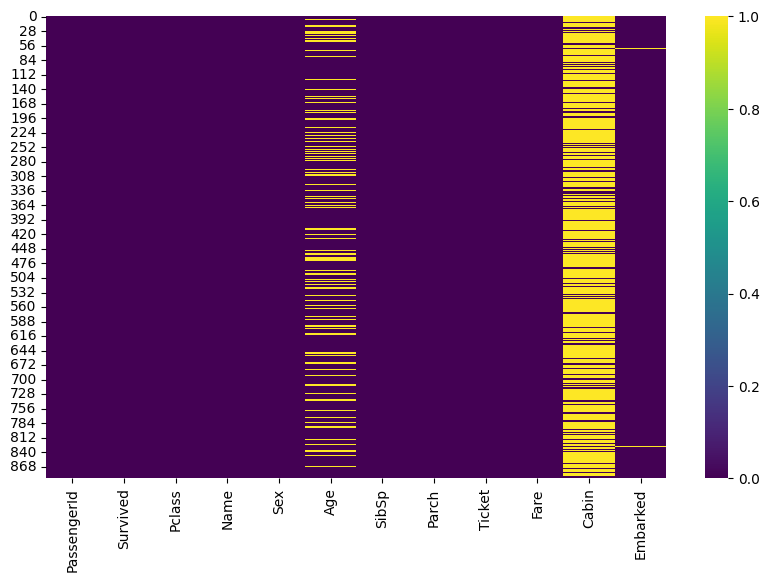

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cmap='viridis')
plt.show()

Visualize through barplot

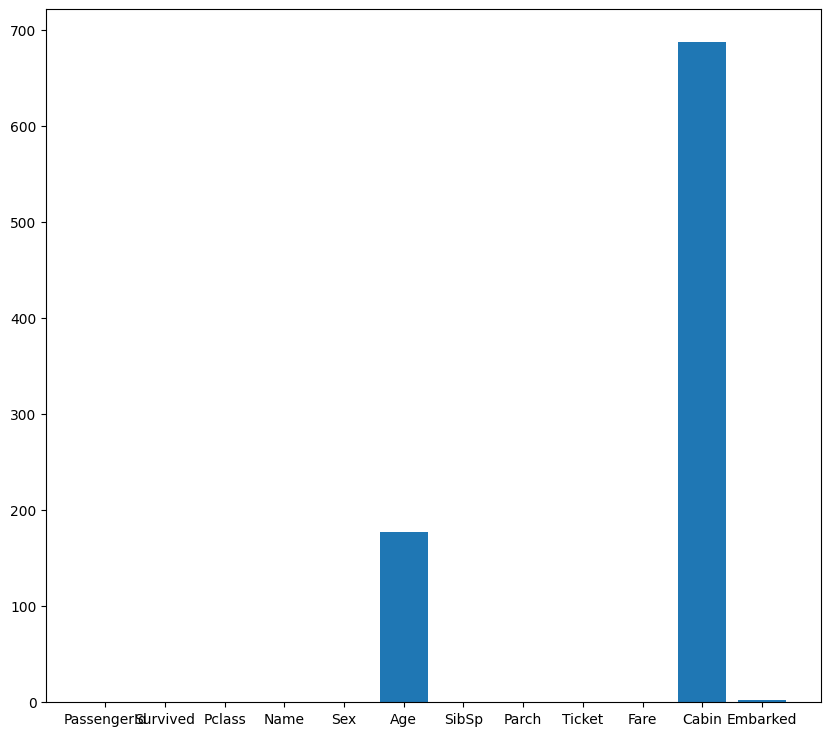

In [ ]:
plt.figure(figsize=(10,9))
plt.bar(df.columns,df.isnull().sum())
plt.show()

**Insight**: Since a lot of data(more than 70%) don't have the cabin , it is advised to just remove this column/feature as it doesn't provide any information to us

In [ ]:
df.drop('Cabin',axis=1,inplace=True)

###5.2 Duplicate Data(rows)

In [ ]:
df.duplicated().sum()

np.int64(0)

###5.3 Unique Values

In [ ]:
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


##6. Univariate Analysis
Univariate analysis is the analysis of one variable at a time. The goal is to understand the characteristics of that single variable without considering its relationship with other variables.







*  To understand the distribution of a variable.
*  To summarize the data using measures like mean, median, and mode.
*  To detect outliers or unusual values.
* Decide whether to normalize, transform, or remove outliers before machine learning.








| Data Type   | Methods                                                               |
| ----------- | --------------------------------------------------------------------- |
| Numerical   | Mean, median, mode, variance, standard deviation, histogram, box plot |
| Categorical | Frequency table, proportions, bar chart, pie chart                    |


###6.1 Numerical Variables

### Histogram

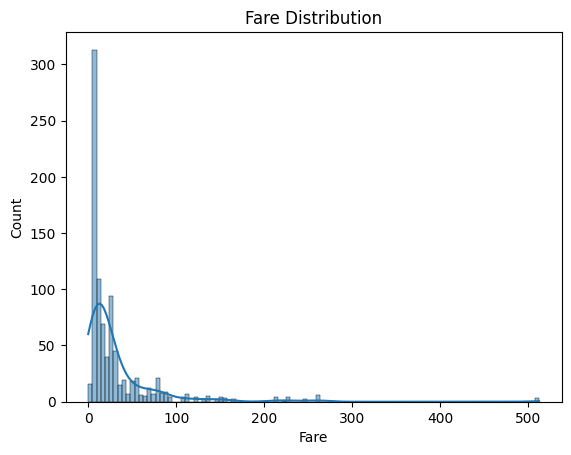

In [ ]:
#Fare
sns.histplot(df["Fare"], kde=True)
plt.title("Fare Distribution")
plt.show()

**Insight** : The Fare feature is highly right-skewed with several valid high-value outliers.Very high fares correspond to first-class passengers or expensive cabins, and Fare is strongly associated with passenger class and survival, making it an important predictive feature.

### Box plot  [max---q3---median---q1---min ]

bahira ko chai outliers maninxa dots hsru


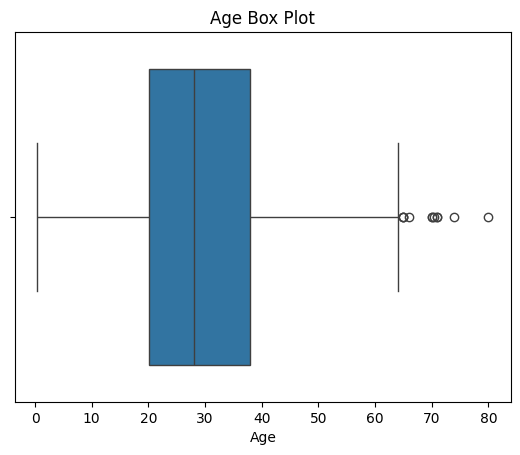

In [ ]:
sns.boxplot(df["Age"].dropna(), orient="h")
plt.title("Age Box Plot")
plt.show()

Box Plot for fair

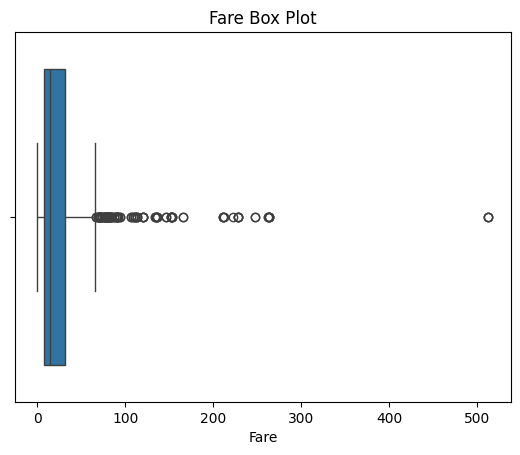

In [ ]:
sns.boxplot(df["Fare"].dropna(), orient="h")
plt.title("Fare Box Plot")
plt.show()

**Insight**: Although Age contains outliers, they will not be removed as they represent valid passenger ages and are an important predictor of survival, not data errors."

In [ ]:
## Do it for Fare
##
##

###6.2 Categorical Features

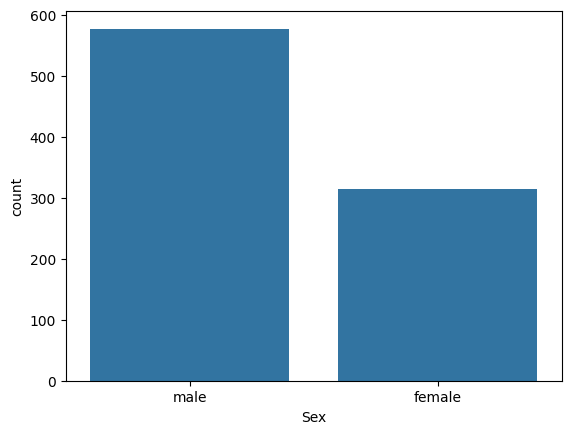

In [ ]:
sns.countplot(data=df,x="Sex")
plt.show()

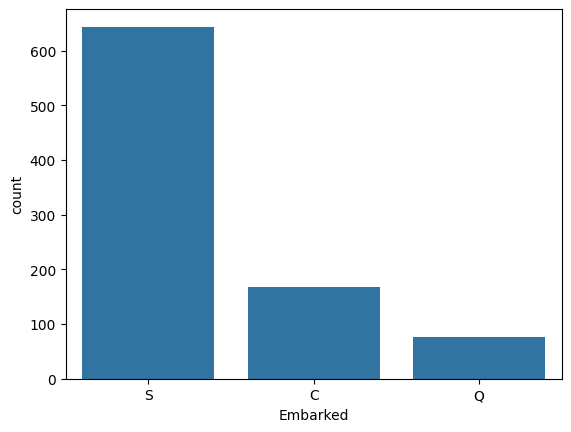

In [ ]:
sns.countplot(data=df,x="Embarked")
plt.show()

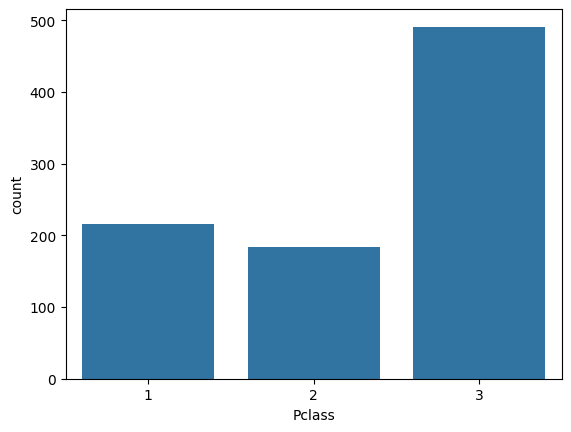

In [ ]:
## Do it for Pclass and Survived
sns.countplot(data=df,x="Pclass")
plt.show()


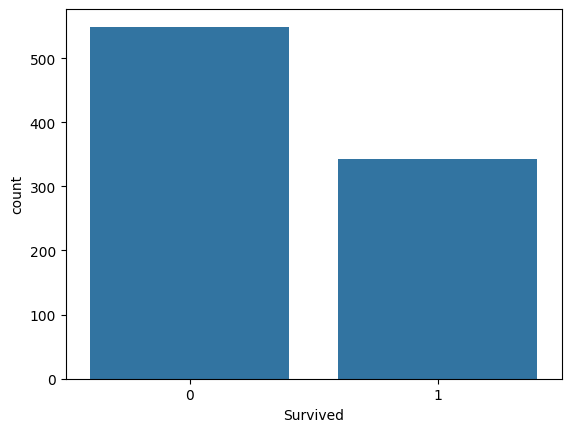

In [ ]:
sns.countplot(data=df,x="Survived")
plt.show()

### Outlier Detection(optional)

In [ ]:
# Q1 = df["column_name"].quantile(0.25)
# Q3 = df["column_name"].quantile(0.75)
# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR

# df = df[(df["column_name"] >= lower) & (df["column_name"] <= upper)]

##7. Bivariate Analysis
Bivariate analysis is done to study the relationship between two variables and determine whether changes in one variable are associated with changes in the other.

<br>

For example:

1.  Gender vs Survival : Does gender play a role in survival
2.  Age vs Survival : Does age have anything to do with survival


### Gender vs Survival

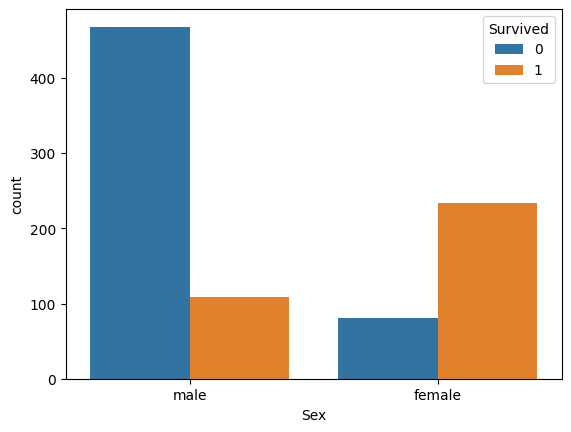

In [ ]:
sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)
plt.show()

**Insight** : Females survived more than men, giving us the insight that females were first priority during evacuation. we can conclude that **Sex** is a important feature for predicting survival

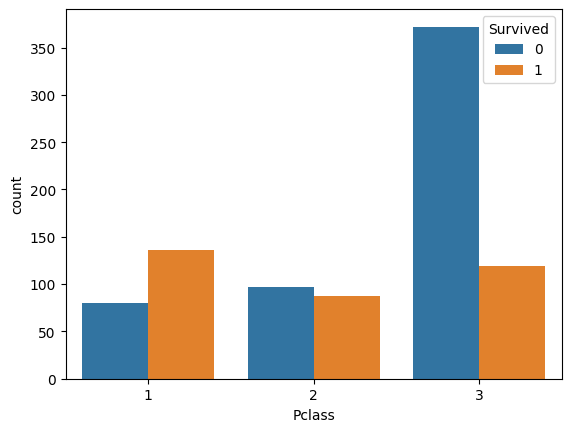

In [ ]:
sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)
plt.show()

**Insight**: We can clearly see that Passenger in 3rd class didnt survived as much as the other two

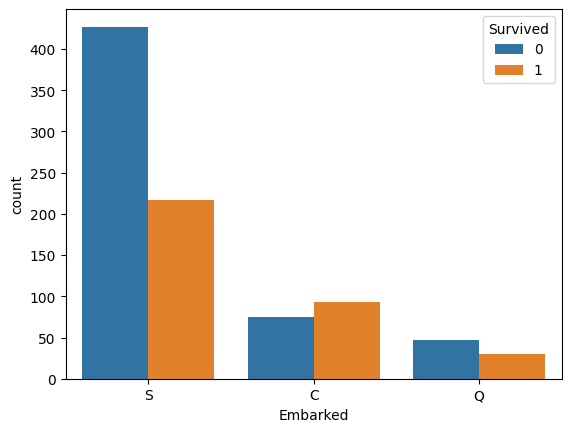

In [ ]:
# !Do the same for Embarked vs Survival,
sns.countplot(
    data=df,
    x="Embarked",
    hue="Survived"
)
plt.show()

In [ ]:
# since age and fare is continous,lets convert it into discrete by creating bins
bins = [0, 12, 19, 39, 59, 100]
labels = ['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior']

df['Age_Bin'] = pd.cut(df['Age'].dropna(), bins=bins, labels=labels)

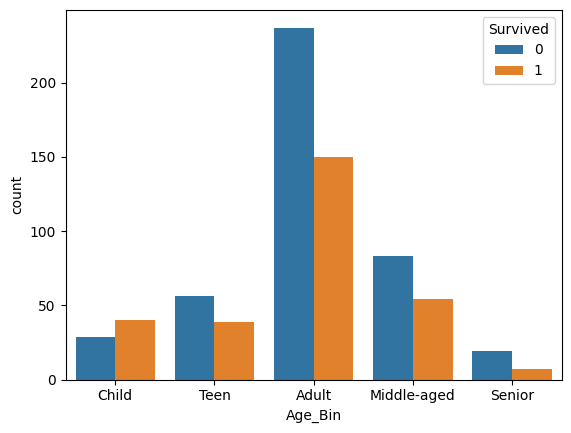

In [ ]:
sns.countplot(data=df, x='Age_Bin', hue='Survived')
plt.show()

**Insight** : We can clearly see children survived the most probably because they evacuated along with their mothers

In [ ]:
fare_bins = [0, 10, 25, 50, 100, df['Fare'].max()]
fare_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['Fare_Bin'] = pd.cut(
    df['Fare'],
    bins=fare_bins,
    labels=fare_labels,
    include_lowest=True
)

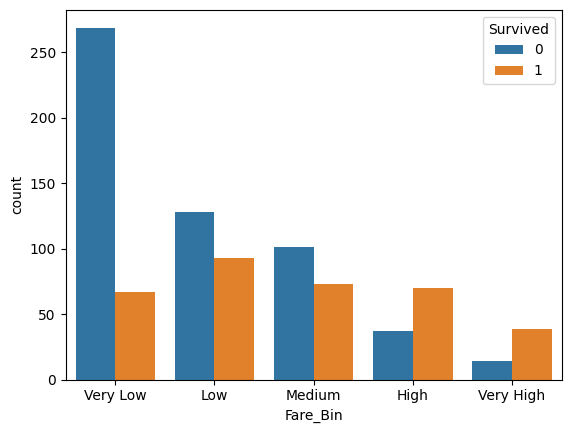

In [ ]:
# do the same for Fare_Bin vs Survived
sns.countplot(data=df, x='Fare_Bin', hue='Survived')
plt.show()

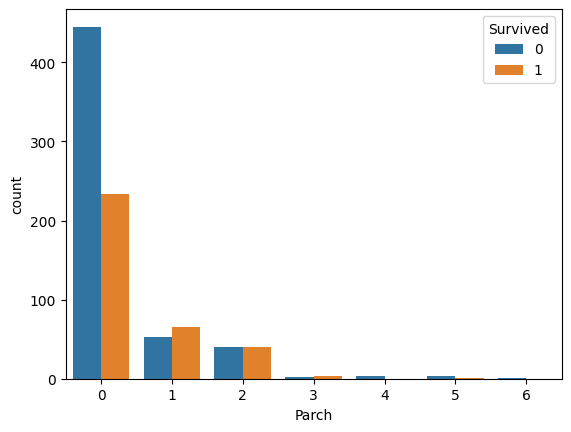

In [ ]:
# do the same for Parch vs Survived
sns.countplot(
    data=df,
    x="Parch",
    hue="Survived"
)
plt.show()

## JO sanga parents siblings xa tyo badi survive garirako xa

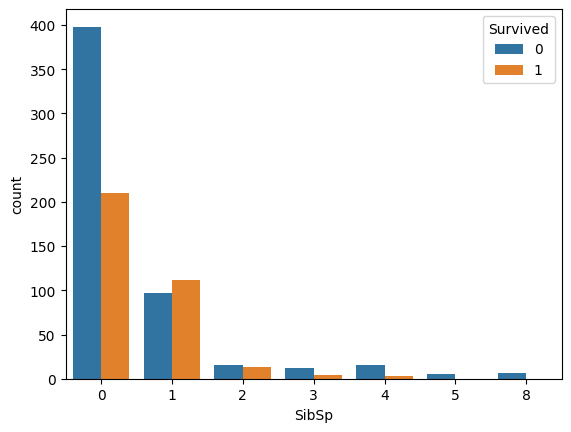

In [ ]:
# do the same for SibSp vs Survived
sns.countplot(
    data=df,
    x="SibSp",
    hue="Survived"
)
plt.show()

##8. Multivariate Analysis

In [ ]:
sns.catplot(
    data=df,
    x="Pclass",
    hue="Survived",
    col="Sex",
    kind="count"
)
plt.show()

NameError: name 'sns' is not defined

**Insights** : Almost all females in 1st class survived , whereas in 3rd class it seems to be equal.Indicating Pclass is stronger indicator than gender

##9. Correlation
Correlation (Pearson Correlation) measures the strength and direction of the linear relationship between two numerical variables.(-1 to 1)



<Axes: >

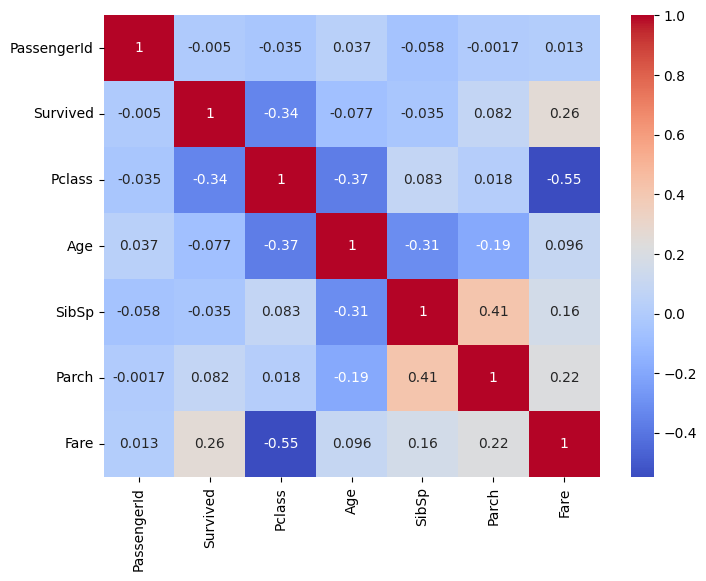

In [ ]:
import numpy as np
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

Clearly see what features have high strength of relationship

**Note**: Correlation detects linear relationships, not causation.


$$
Correlation \neq Causation
$$

**Note**: Be careful with **multicollinearity**. when using Linear Models as they could degrade performance

##10. Modeling and Machine Learning
EDA is finished now we must prepare the data to go into our model

###10.1 Preparing the data for modeling

In [ ]:
df = df.drop(   # yena harle survaivle ma farak pardena
    columns=[
        "PassengerId",
        "Name",
        "Ticket"
    ]
)

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median()) #age khali bhako thau ma median haldiyo
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0]) #most frequent location le fill null

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Age_Bin,177
Fare_Bin,0


### Hot one encoding for (Categorical -> Numerical)

In [ ]:
df.select_dtypes(include="object").columns

Index(['Sex', 'Embarked'], dtype='object')

In [ ]:
df = pd.get_dummies(df,drop_first=True)

###10.2 Setting the target(y) and features(X)
For simplicity we have selected every feature

In [ ]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

In [ ]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Age_Bin_Teen,Age_Bin_Adult,Age_Bin_Middle-aged,Age_Bin_Senior,Fare_Bin_Low,Fare_Bin_Medium,Fare_Bin_High,Fare_Bin_Very High
0,3,22.0,1,0,7.2500,True,False,True,False,True,False,False,False,False,False,False
1,1,38.0,1,0,71.2833,False,False,False,False,True,False,False,False,False,True,False
2,3,26.0,0,0,7.9250,False,False,True,False,True,False,False,False,False,False,False
3,1,35.0,1,0,53.1000,False,False,True,False,True,False,False,False,False,True,False
4,3,35.0,0,0,8.0500,True,False,True,False,True,False,False,False,False,False,False


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Pclass               891 non-null    int64  
 1   Age                  891 non-null    float64
 2   SibSp                891 non-null    int64  
 3   Parch                891 non-null    int64  
 4   Fare                 891 non-null    float64
 5   Sex_male             891 non-null    bool   
 6   Embarked_Q           891 non-null    bool   
 7   Embarked_S           891 non-null    bool   
 8   Age_Bin_Teen         891 non-null    bool   
 9   Age_Bin_Adult        891 non-null    bool   
 10  Age_Bin_Middle-aged  891 non-null    bool   
 11  Age_Bin_Senior       891 non-null    bool   
 12  Fare_Bin_Low         891 non-null    bool   
 13  Fare_Bin_Medium      891 non-null    bool   
 14  Fare_Bin_High        891 non-null    bool   
 15  Fare_Bin_Very High   891 non-null    boo

###10.3 Spliting the dataset into Train and Test

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

###10.4 Training the Model

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)



LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(
    X_test
)

In [ ]:
y_pred[:10]

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0])

## Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7989


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



$$
\text{Recall} = \frac{TP}{TP + FN}
$$

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

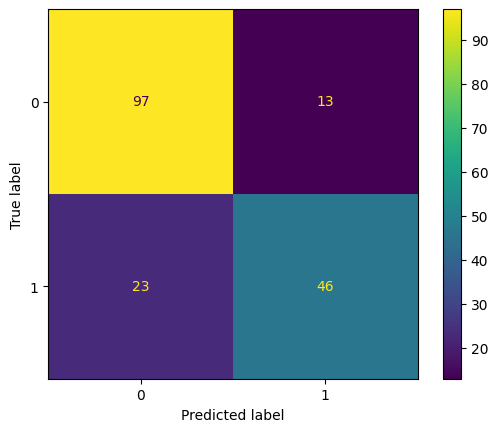

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()